In [6]:
import pandas as pd
import numpy as np

print("Jupyter is working!")

Jupyter is working!


In [7]:
import re
import json
import importlib
import utils
importlib.reload(utils)

<module 'utils' from '/Users/lovedeep/work/git/ai-engineering/andrewng-course-agenticai/course-modules/Reflection-Design-Pattern/utils.py'>

In [8]:
df = utils.load_and_prepare_data('coffee_sales.csv')

In [9]:
utils.print_html(df.sample(n=5), title="Random Sample of Coffee Sales Data")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2025-03-19,12:41,card,ANON-0000-0000-1158,3.576,Cappuccino,1,3,2025
2024-05-24,09:50,card,ANON-0000-0000-0209,2.792,Cortado,2,5,2024
2024-03-11,08:22,cash,NaN,3.000,Cortado,1,3,2024
2024-09-09,09:15,card,ANON-0000-0000-0583,3.282,Hot Chocolate,3,9,2024
2024-06-12,07:03,card,ANON-0000-0000-0288,3.772,Hot Chocolate,2,6,2024


In [10]:
print(df.columns)

Index(['date', 'time', 'cash_type', 'card', 'price', 'coffee_name', 'quarter',
       'month', 'year'],
      dtype='str')


In [11]:
import matplotlib
from openai import OpenAI
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

In [12]:
load_dotenv()

True

In [13]:
def generate_chart_code(question: str, model: str, output_path_v1: str) -> str:
    prompt = f"""
    You are a Python data analyst.

    Dataset schema:
    {schema}

    User question:
    {question}

    Rules:
    - Use pandas and matplotlib only.
    - Read data from coffee_sales.csv.
    - Return only Python code inside <execute_python> and </execute_python> tags.
    - Save the output chart as '{output_path_v1}'
    - Do not explain anything.
    - Do not create the dataframe again, we already have that ready as df
    """
    llm = ChatOpenAI(
        model=model,
        temperature=1
    )
    response = llm.invoke(prompt)
    return response.content
    


In [14]:
schema = """
coffee_sales.csv columns:
- date: sale date
- time: sale time
- cash_type: cash or card
- card: anonymized card id
- price: sale amount / revenue
- coffee_name: coffee product name
- quarter: quarter number
- month: month number
- year: year
"""

In [15]:
question = "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv."

In [16]:
code_v1 = generate_chart_code(
    model="gpt-4.1-mini",
    question="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    output_path_v1="chart_v1.png"
)

In [17]:
print(code_v1)

<execute_python>
import matplotlib.pyplot as plt

# Filter data for Q1 2024 and Q1 2025
df_q1 = df[(df['quarter'] == 1) & (df['year'].isin([2024, 2025]))]

# Aggregate sales by month and year
sales_q1 = df_q1.groupby(['year', 'month'])['price'].sum().unstack(level=0)

# Plot
fig, ax = plt.subplots()
sales_q1.plot(kind='bar', ax=ax)
ax.set_title('Q1 Coffee Sales Comparison: 2024 vs 2025')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
ax.legend(title='Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart_v1.png')
plt.close()
</execute_python>


In [18]:
utils.print_code_html(code_v1, title="LLM outputting the code")


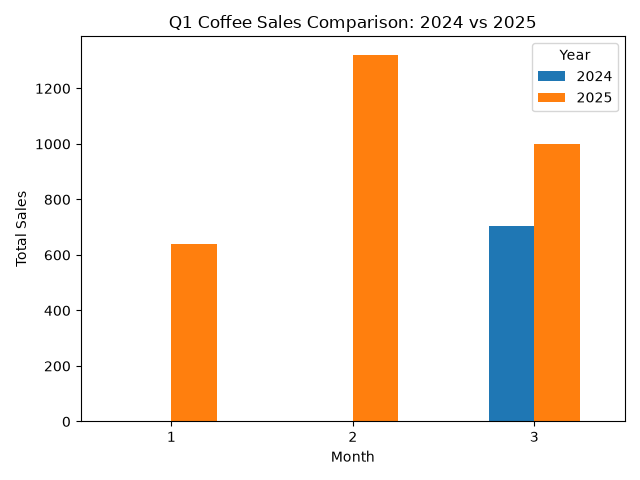

In [19]:
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match:
    initial_code = match.group(1).strip()
    utils.print_code_html(initial_code, title="Extracted Code to Execute")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

utils.print_html(
    content="chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)

In [20]:
from langchain_core.messages import HumanMessage
import mimetypes

In [21]:
def reflect_on_image_and_regenerate( chart_path: str, schema: str, instruction: str, model: str, output_path_v2: str, code_v1: str):
    """
    The goal here is to simulate how a human would review a first draft of a chart—looking for strengths, weaknesses, and areas for improvement.
    Here’s what happens:
    1. Provide the chart to the LLM: The generated chart (chart_v1.png) is shared with the LLM so it can “see” the visualization.
    2. Analyze the chart visually: The LLM reviews elements like clarity, labeling, accuracy, and overall readability.
    3. Generate feedback: The LLM suggests improvements—for example, fixing axis labels, adjusting the chart type, improving color choices, or highlighting missing legends.
    """

    media_type, b64 = utils.encode_image_b64(chart_path)

    prompt = f"""
    You are a Python data analyst.
    Your task: I will share you a chart png file and python code which generated that chart.
    Visualize the chart & code, further analyze it from clarity, labeling, accuracy and overall readability perspective. 
    Then gather your feedback and re-create a new code python code for me inside <execute_python> tags.

    Dataset schema:
    {schema}

    User instructions:
    {instruction}

    code:
    {code_v1}

    chart:
    {chart_path}

    Rules:
    - Use pandas and matplotlib only.
    - Return Python code inside <execute_python> and </execute_python> tags.
    - Save the output chart as '{output_path_v2}'
    - Do not explain anything and I expect 2 things from you and nothing i.e. feedback and python code
    - Do not create the dataframe again, we already have that ready as df
    - datetime is already datetime object

    <feedback>
    Your concise feedback here.
    </feedback>

    <execute_python>
    Python code here.
    </execute_python>
    
    """
    llm = ChatOpenAI(
        model=model,
        temperature=1
    )
    message = HumanMessage(
        content=[
            {
                "type": "text",
                "text": prompt
            },
            {
                "type": "image_url",
                "image_url": {
                    "url": f"data:{media_type};base64,{b64}"
                }
            }
        ]
    )
    response = llm.invoke([message])
    content = response.content

    feedback_match = re.search(
        r"<feedback>(.*?)</feedback>",
        content,
        re.DOTALL
    )

    code_match = re.search(
        r"<execute_python>(.*?)</execute_python>",
        content,
        re.DOTALL
    )

    feedback = feedback_match.group(1).strip() if feedback_match else ""
    code_v2 = code_match.group(1).strip() if code_match else ""
    return feedback, code_v2

In [22]:
feedback, code_v2 = reflect_on_image_and_regenerate(
    model="gpt-4.1-mini",
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
    chart_path="chart_v1.png",
    output_path_v2="chart_v2.png",
    code_v1=code_v1,
    schema=schema
)

In [23]:
utils.print_html(feedback, title="Feedback on V1 Chart")
utils.print_html(code_v2, title="Regenerated Code Output (V2)")

NameError: name 'pd' is not defined

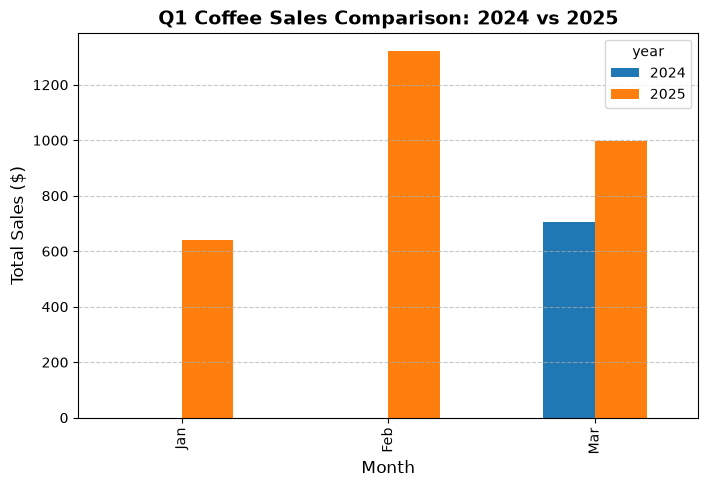

In [24]:
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if feedback:
    #initial_code = match.group(1).strip()
    utils.print_code_html(code_v2, title="Extracted Code to Execute")
    exec_globals = {"df": df}
    exec(code_v2, exec_globals)



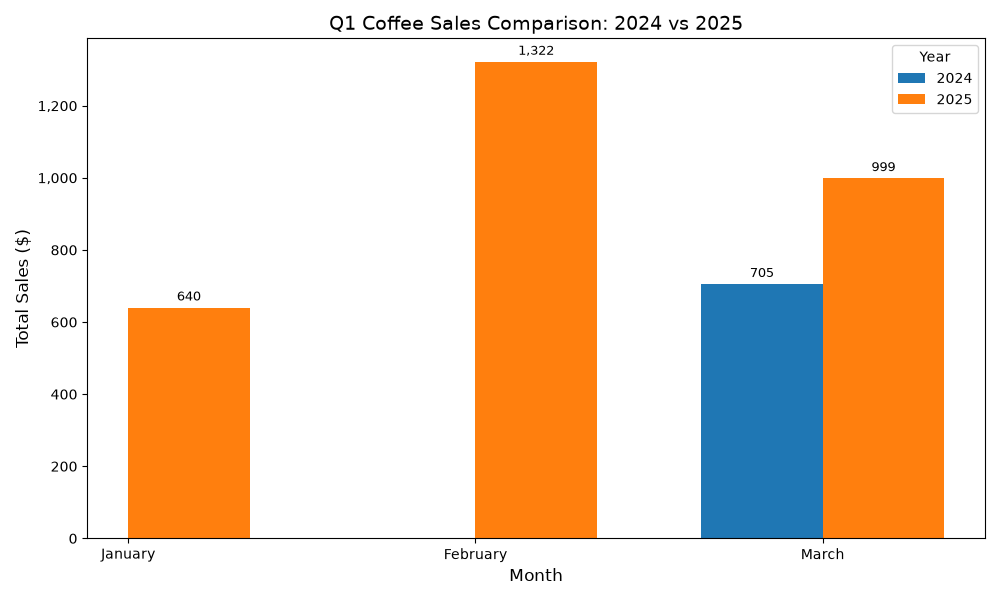

In [25]:
utils.print_html(
    content="chart_v2.png",
    title="Generated Chart (V1)",
    is_image=True
)

In [32]:
def my_first_workflow(dataset: str, instructions: str, schema: str):
    """
    End to End flow:
    - load dataset
    - generate v1 codde and execute it to produce chartv1
    - reflect on both code_v1 and chatv1.png and provide feedback with new code
    - execute new code and create chartv2.png
    """
    df = utils.load_and_prepare_data(dataset)
    utils.print_html(df.sample(n=5), title="Random Sample of Coffee Sales Data")

    # code v1
    # calling the funtion to generate the chart code
    code_v1 = generate_chart_code(
        model="gpt-4.1-mini",
        question="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
        output_path_v1="chart_v1.png"
    )
    
    # printing code v1
    utils.print_code_html(code_v1, title="LLM outputting the code")

    # execution of code v1 with df as dataset
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
    if match:
        initial_code = match.group(1).strip()
        utils.print_code_html(initial_code, title="Extracted Code to Execute")
        exec_globals = {"df": df}
        exec(initial_code, exec_globals)

    # printing chart v1
    chart_v1 = utils.print_html(
        content="chart_v1.png",
        title="Generated Chart (V1)",
        is_image=True
    )

    # code v2
    # calling the function to reflect and regenrate python code and feeadback
    feedback, code_v2 = reflect_on_image_and_regenerate(
        model="gpt-4.1-mini",
        instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
        chart_path="chart_v1.png",
        output_path_v2="chart_v2.png",
        code_v1=code_v1,
        schema=schema
    )

    # print of feedback and code v2
    utils.print_html(feedback, title="Feedback on V1 Chart")
    utils.print_html(code_v2, title="Regenerated Code Output (V2)")

    # execution of code v2 with df as dataset
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
    if feedback:
        #initial_code = match.group(1).strip()
        utils.print_code_html(code_v2, title="Extracted Code to Execute")
        exec_globals = {"df": df}
        exec(code_v2, exec_globals)
        
    # printing chart v2
    chart_v2 = utils.print_html(
        content="chart_v2.png",
        title="Generated Chart (V1)",
        is_image=True
    )

    return {
        "code_v1": code_v1,
        "chart_v1": chart_v1,
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": chart_v2,
    }
    

date,time,cash_type,card,price,coffee_name,quarter,month,year
2025-02-05,16:08,card,ANON-0000-0000-1181,3.576,Cappuccino,1,2,2025
2024-04-14,12:43,card,ANON-0000-0000-0012,2.890,Americano,2,4,2024
2024-09-19,13:41,card,ANON-0000-0000-0004,2.302,Americano,3,9,2024
2024-09-17,07:51,card,ANON-0000-0000-0627,2.302,Cortado,3,9,2024
2024-06-13,11:56,card,ANON-0000-0000-0295,3.772,Hot Chocolate,2,6,2024



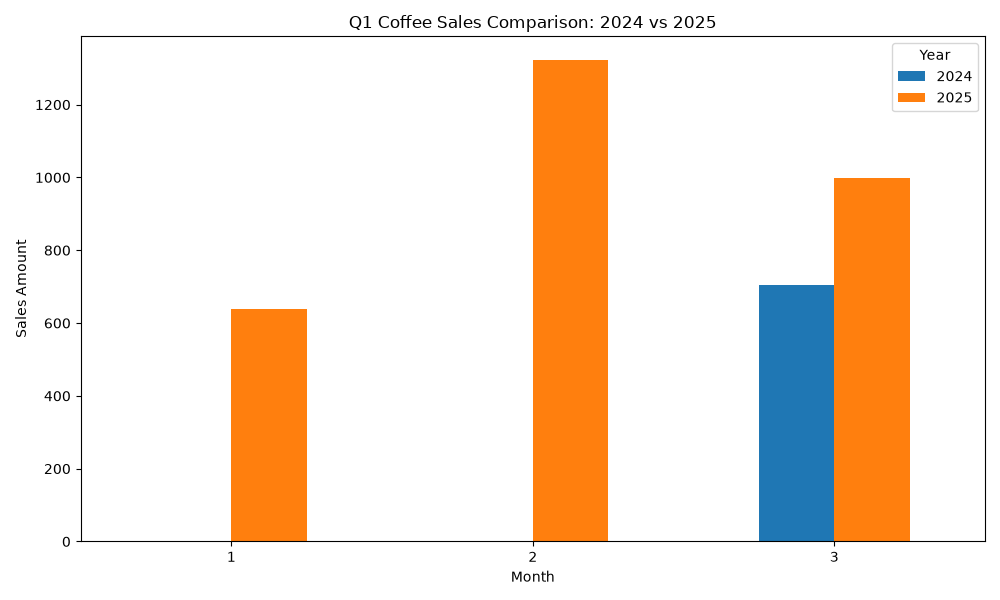


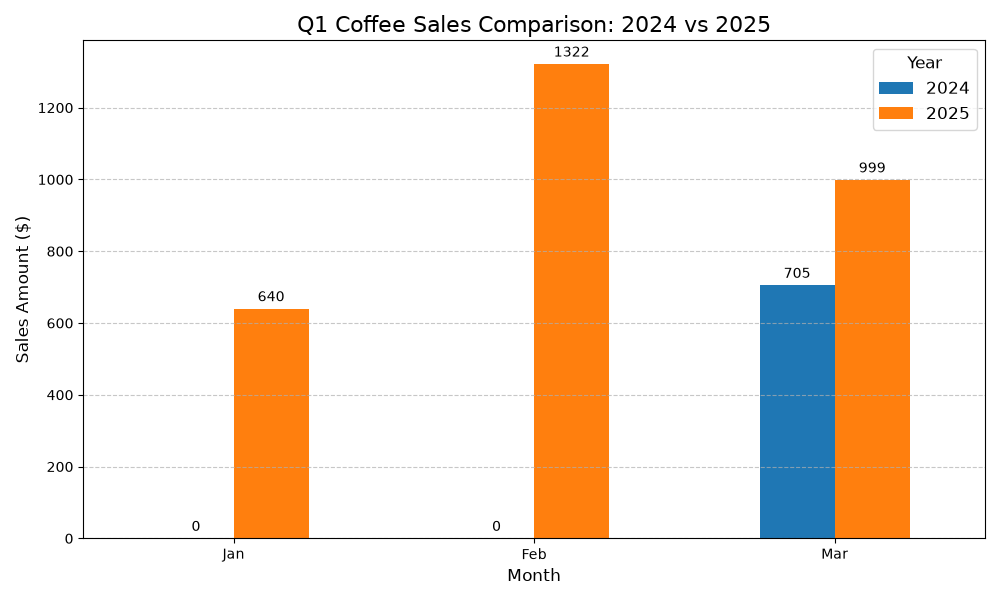

In [33]:
data="coffee_sales.csv"
instructions="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv."
schema = """
coffee_sales.csv columns:
- date: sale date
- time: sale time
- cash_type: cash or card
- card: anonymized card id
- price: sale amount / revenue
- coffee_name: coffee product name
- quarter: quarter number
- month: month number
- year: year
"""
result = my_first_workflow(
    dataset=data,
    instructions=instructions,
    schema=schema
)

In [2]:
from langchain.agents import create_agent

In [ ]:
def load_data_step(dataset: str):
    df = utils.load_and_prepare_data(state["dataset"])

    utils.print_html(
        df.sample(n=5),
        title="Random Sample of Coffee Sales Data"
    )
    return df

def generate_code_v1(model: str, new_chart_v1: str):
    # code v1
    # calling the funtion to generate the chart code
    code_v1 = generate_chart_code(
        model={model},
        question="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
        output_path_v1={new_chart_v1}
    )
    
    # printing code v1
    utils.print_code_html(code_v1, title="LLM outputting the code")

    # execution of code v1 with df as dataset
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
    if match:
        initial_code = match.group(1).strip()
        utils.print_code_html(initial_code, title="Extracted Code to Execute")
        exec_globals = {"df": df}
        exec(initial_code, exec_globals)

    # printing chart v1
    chart_v1 = utils.print_html(
        content={new_chart_v1},
        title="Generated Chart (V1)",
        is_image=True
    )

    return {
        "code_v1": code_v1,
        "chart_v1": chart_v1
    }

def generate_code_v2(model: str, new_chart_v1: str, {new_chart_v2}: str ):
    # code v2
    # calling the function to reflect and regenrate python code and feeadback
    feedback, code_v2 = reflect_on_image_and_regenerate(
        model={model},
        instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.",
        chart_path={new_chart_v1},
        output_path_v2={new_chart_v2},
        code_v1=code_v1,
        schema=schema
    )

    # print of feedback and code v2
    utils.print_html(feedback, title="Feedback on V1 Chart")
    utils.print_html(code_v2, title="Regenerated Code Output (V2)")

    # execution of code v2 with df as dataset
    match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
    if feedback:
        #initial_code = match.group(1).strip()
        utils.print_code_html(code_v2, title="Extracted Code to Execute")
        exec_globals = {"df": df}
        exec(code_v2, exec_globals)
        
    # printing chart v2
    chart_v2 = utils.print_html(
        content={new_chart_v2},
        title="Generated Chart (V1)",
        is_image=True
    )

    return {
        "feedback": feedback,
        "code_v2": code_v2,
        "chart_v2": chart_v2,
    }

agent = create_agent(
    model="openai:gpt-4.1-mini",
    tools=[load_data_step, generate_code_v1, generate_code_v2],
    system_prompt="You are a data visualization expert",
)

dataset="coffee_sales.csv"
model="gpt-4.1-mini"
new_chart_v1="new_chart_v1.png"
new_chart_v2="new_chart_v2.png"
schema = """
coffee_sales.csv columns:
- date: sale date
- time: sale time
- cash_type: cash or card
- card: anonymized card id
- price: sale amount / revenue
- coffee_name: coffee product name
- quarter: quarter number
- month: month number
- year: year
"""

result = agent.invoke(
    {"messages": [{"role": "user", "content": "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in {dataset} using model {model} using schema {schema} and create charts {new_chart_v1} {new_chart_v2}"}]}
)
print(result["messages"][-1].content_blocks)
    